In [ ]:
import pandas as pd
import numpy as np
import os, requests
from concurrent.futures import ThreadPoolExecutor
from PIL import Image
from io import BytesIO


In [ ]:
# Local paths for VS Code
BASE_DIR = os.path.join(os.getcwd(), 'cv_project')
IMAGE_DIR = os.path.join(BASE_DIR, 'images')
os.makedirs(IMAGE_DIR, exist_ok=True)


Mounted at /content/drive


In [ ]:
# ── 1. LOAD ──────────────────────────────────────────────────────────────────
df = pd.read_csv('housing.csv')
print(f"Raw shape: {df.shape}")


Raw shape: (8983, 42)


In [ ]:
# ── 2. DROP JUNK COLUMNS ─────────────────────────────────────────────────────
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 40'])


In [ ]:

# ── 3. CLEAN NUMERIC COLUMNS ─────────────────────────────────────────────────

# sqft_lot:
if df['sqft_lot'].dtype == object:
    df['sqft_lot'] = df['sqft_lot'].str.replace(',', '').str.extract(r'(\d+\.?\d*)').astype(float)

# price_per_sqft: "$450/sqft" or similar
if df['price_per_sqft'].dtype == object:
    df['price_per_sqft'] = df['price_per_sqft'].str.replace(r'[\$,/sqft\s]', '', regex=True).astype(float)

# Walk/bike scores: "81/100" → 81.0
for col in ['walk_score', 'bike_score', 'transit_score']:
    if col in df.columns and df[col].dtype == object:
        df[col] = df[col].str.extract(r'(\d+)').astype(float)

# estimated_monthly_payment: "$4,200/mo" → 4200.0
df['estimated_monthly_payment'] = df['estimated_monthly_payment'].str.extract(r'(\d+\.?\d*)').astype(float)


In [ ]:
# ── 4. STANDARDIZE CATEGORICALS ──────────────────────────────────────────────
df['property_type'] = df['property_type'].str.lower().str.strip()


In [ ]:
# ── 5. HANDLE MISSING VALUES ─────────────────────────────────────────────────
# Drop rows missing the most critical fields
df = df.dropna(subset=['price', 'image_url', 'beds', 'sqft'])

# Drop transit_score — 65% null, not worth imputing
df = df.drop(columns=['transit_score'])

# Impute numeric cols with median
for col in ['baths', 'year_built', 'walk_score', 'bike_score',
            'parking_total_spaces', 'garage_spaces']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print(f"After cleaning: {df.shape}")


After cleaning: (8575, 39)


In [ ]:
# ── 6. REMOVE PRICE OUTLIERS ─────────────────────────────────────────────────
q_low  = df['price'].quantile(0.01)
q_high = df['price'].quantile(0.99)
df = df[(df['price'] >= q_low) & (df['price'] <= q_high)]
print(f"After outlier removal: {df.shape}")
print(f"Price range: ${df['price'].min():,.0f} – ${df['price'].max():,.0f}")


After outlier removal: (8406, 39)
Price range: $150,000 – $11,495,000


In [ ]:
# ── 7. DOWNLOAD IMAGES ───────────────────────────────────────────────────────
def download_image(row):
    img_id  = str(row['url']).split('/')[-2]   # stable ID from Zillow URL
    img_path = f"{IMAGE_DIR}/{img_id}.jpg"
    if os.path.exists(img_path):
        return img_path
    try:
        r = requests.get(row['image_url'], timeout=10, headers={'User-Agent': 'Mozilla/5.0'})
        img = Image.open(BytesIO(r.content)).convert('RGB')
        img = img.resize((224, 224))
        img.save(img_path)
        return img_path
    except Exception as e:
        return None

print("Downloading images...")
with ThreadPoolExecutor(max_workers=8) as ex:
    df['img_path'] = list(ex.map(download_image, [row for _, row in df.iterrows()]))

# Keep only rows where download succeeded
df = df[df['img_path'].notna()]
print(f"Listings with images: {len(df)}")


Listings with images: 8400


In [ ]:
# ── 8. SAVE CLEAN MANIFEST ───────────────────────────────────────────────────
df.to_csv(os.path.join(BASE_DIR, 'listings_clean.csv'), index=False)
print("Saved listings_clean.csv")


Saved listings_clean.csv


# Training


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [ ]:
# ── 1. LOAD CLEAN MANIFEST ───────────────────────────────────────────────────
BASE_DIR = os.path.join(os.getcwd(), 'cv_project')
df = pd.read_csv(os.path.join(BASE_DIR, 'listings_clean.csv'))


In [ ]:
# ── 2. SELECT TABULAR FEATURES ───────────────────────────────────────────────
FEATURES = ['beds', 'baths', 'sqft', 'year_built',
            'walk_score', 'bike_score',
            'parking_total_spaces']

TARGET = 'price'

# One-hot encode property_type and region
df = pd.get_dummies(df, columns=['property_type', 'region'], drop_first=True)

# Add any new one-hot columns to features
ohe_cols = [c for c in df.columns if c.startswith('property_type_') or c.startswith('region_')]
FEATURES = FEATURES + ohe_cols


In [ ]:
# ── 3. PREPARE X, y ──────────────────────────────────────────────────────────
X = df[FEATURES].fillna(df[FEATURES].median())
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


In [ ]:
# ── 4. TRAIN ALL THREE MODELS ─────────────────────────────────────────────────
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    # Linear regression uses scaled features, trees don't need it
    X_tr = X_train_sc if name == 'Linear Regression' else X_train
    X_te = X_test_sc  if name == 'Linear Regression' else X_test

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)

    results[name] = {
        'MAE':  mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2':   r2_score(y_test, preds),
        'preds': preds
    }
    print(f"{name:20s} | MAE: ${results[name]['MAE']:>10,.0f} | RMSE: ${results[name]['RMSE']:>10,.0f} | R²: {results[name]['R2']:.3f}")


Linear Regression    | MAE: $   454,763 | RMSE: $   864,014 | R²: 0.562
Decision Tree        | MAE: $   447,928 | RMSE: $   877,647 | R²: 0.548
Random Forest        | MAE: $   354,096 | RMSE: $   711,010 | R²: 0.703


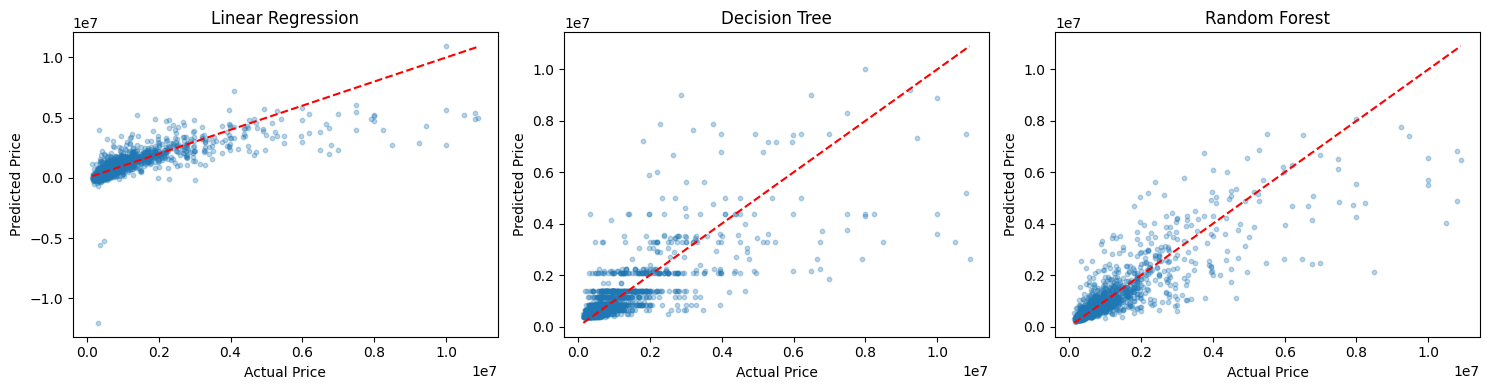

In [ ]:
# ── 5. PLOT: PREDICTED VS ACTUAL ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    ax.scatter(y_test, res['preds'], alpha=0.3, s=10)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_title(name)
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'baseline_predictions.png'))
plt.show()


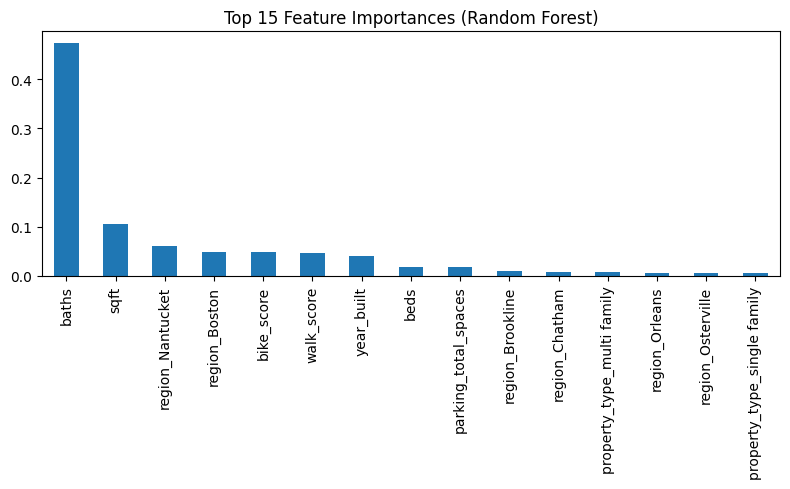

In [ ]:
# ── 6. FEATURE IMPORTANCE (Random Forest) ────────────────────────────────────
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
importances.plot(kind='bar')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'feature_importance.png'))
plt.show()


In [ ]:
print(df['price'].describe())
print(df[df['price'] > 5_000_000][['address', 'price', 'sqft']].head(10))


count    8.400000e+03
mean     1.164897e+06
std      1.331108e+06
min      1.500000e+05
25%      4.999000e+05
50%      7.477000e+05
75%      1.225000e+06
max      1.149500e+07
Name: price, dtype: float64
                                          address      price     sqft
233          0 Gulf Rd, South Dartmouth, MA 02748  5495000.0   5528.0
298         150 Horseneck Rd, Dartmouth, MA 02748  8900000.0  13220.0
344              20 Eliot Ave, Chilmark, MA 02535  6595000.0   3052.0
546             52 Fuller St, Edgartown, MA 02539  9250000.0   6881.0
597   1210 Graces Cove Rd, Block Island, RI 02807  7495000.0   5571.0
633  272 Carnegie Harbor Dr, Portsmouth, RI 02871  6595000.0  10556.0
656         31 Moss Road, West Yarmouth, MA 02673  5995000.0   4173.0
665         41 Castle Hill Ave, Newport, RI 02840  9999999.0  11293.0
666           2 Harbor View Dr, Newport, RI 02840  9500000.0   5983.0
749             2 Hingham St, Cambridge, MA 02138  6195000.0   8160.0
